In [13]:
# Import Libraries

import pandas as pd
import numpy as np
import joblib
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix, precision_recall_curve
from xgboost import XGBClassifier 
from sklearn.model_selection import RandomizedSearchCV   

import warnings
warnings.filterwarnings("ignore")

In [2]:
# Load Dataset
df = pd.read_csv("../datasets/noshowappointments.csv")

print("Dataset Shape:", df.shape)
df.head()

Dataset Shape: (110527, 14)


,PatientId,AppointmentID,Gender,ScheduledDay,AppointmentDay,Age,Neighbourhood,Scholarship,Hipertension,Diabetes,Alcoholism,Handcap,SMS_received,No-show
0,2.987250e+13,5642903,F,2016-04-29T18:38:08Z,2016-04-29T00:00:00Z,62,JARDIM DA PENHA,0,1,0,0,0,0,No
1,5.589978e+14,5642503,M,2016-04-29T16:08:27Z,2016-04-29T00:00:00Z,56,JARDIM DA PENHA,0,0,0,0,0,0,No
2,4.262962e+12,5642549,F,2016-04-29T16:19:04Z,2016-04-29T00:00:00Z,62,MATA DA PRAIA,0,0,0,0,0,0,No
3,8.679512e+11,5642828,F,2016-04-29T17:29:31Z,2016-04-29T00:00:00Z,8,PONTAL DE CAMBURI,0,0,0,0,0,0,No
4,8.841186e+12,5642494,F,2016-04-29T16:07:23Z,2016-04-29T00:00:00Z,56,JARDIM DA PENHA,0,1,1,0,0,0,No


In [3]:
# Standardize columns
df.columns = df.columns.str.lower().str.replace("-", "_").str.strip()

# Convert Target to Binary
df["no_show_numeric"] = df["no_show"].map({"No": 0, "Yes": 1})

In [4]:
# Dates and Sorting (Critical for History)
df["scheduledday"] = pd.to_datetime(df["scheduledday"])
df["appointmentday"] = pd.to_datetime(df["appointmentday"]).dt.normalize()
df = df.sort_values(by=['patientid', 'scheduledday'])

In [5]:
# 3. BEHAVIORAL FEATURE ENGINEERING
# ==========================================
# Creating features based on past behavior (The "History" effect)
df['prev_noshows_count'] = df.groupby('patientid')['no_show_numeric'].shift(1).fillna(0)
df['prev_noshows_cumsum'] = df.groupby('patientid')['prev_noshows_count'].cumsum()
df['total_prev_appts'] = df.groupby('patientid').cumcount()

# No-show Rate (Preventing division by zero)
df['noshow_rate'] = np.where(df['total_prev_appts'] > 0, 
                             df['prev_noshows_cumsum'] / df['total_prev_appts'], 
                             0)

In [6]:
# Time-based Logic
df["waiting_days"] = (df["appointmentday"] - df["scheduledday"].dt.normalize()).dt.days
df = df[df["waiting_days"] >= 0].copy() 
df["is_same_day"] = (df["waiting_days"] == 0).astype(int)
df["day_of_week"] = df["appointmentday"].dt.dayofweek

In [7]:
# 4. PREPROCESSING & ALIGNMENT
# ==========================================
features = ['age', 'gender', 'scholarship', 'hipertension', 'diabetes', 
            'alcoholism', 'handcap', 'sms_received', 'waiting_days', 
            'is_same_day', 'day_of_week', 'prev_noshows_cumsum', 'noshow_rate']

df["gender"] = df["gender"].map({"F": 0, "M": 1})

In [8]:
# The Safety Net: Clear all potential NaNs from target or features
df_final = df[features + ["no_show_numeric"]].dropna()
X = df_final[features]
y = df_final["no_show_numeric"]

# Train Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [11]:
# 5. HYPERPARAMETER TUNING (THE IMPROVEMENT)
# ==========================================
# Calculate balance ratio
ratio = (y_train == 0).sum() / (y_train == 1).sum()

param_dist = {
    'n_estimators': [300, 500],
    'max_depth': [4, 6, 8],
    'learning_rate': [0.01, 0.05, 0.1],
    'subsample': [0.7, 0.8, 0.9],
    'colsample_bytree': [0.7, 0.8]
}

print("Optimizing model parameters... please wait.")
random_search = RandomizedSearchCV(
    XGBClassifier(scale_pos_weight=ratio, eval_metric='logloss', random_state=42),
    param_distributions=param_dist,
    n_iter=10, 
    scoring='roc_auc',
    cv=3,
    n_jobs=-1,
    random_state=42
)

random_search.fit(X_train, y_train)
model = random_search.best_estimator_

Optimizing model parameters... please wait.


In [14]:
# 6. FINAL EVALUATION
# ==========================================
y_prob = model.predict_proba(X_test)[:, 1]

# Dynamic Thresholding for "Perfect" Balance
precisions, recalls, thresholds = precision_recall_curve(y_test, y_prob)
f1_scores = 2 * (precisions * recalls) / (precisions + recalls)
best_threshold = thresholds[np.argmax(f1_scores)]

y_pred = (y_prob >= best_threshold).astype(int)

print(f"\n--- IMPROVED MODEL PERFORMANCE ---")
print(f"ROC-AUC Score: {roc_auc_score(y_test, y_prob):.4f}")
print(f"Optimal Threshold: {best_threshold:.4f}")
print(classification_report(y_test, y_pred))


--- IMPROVED MODEL PERFORMANCE ---
ROC-AUC Score: 0.7397
Optimal Threshold: 0.5294
              precision    recall  f1-score   support

           0       0.91      0.59      0.72     17642
           1       0.32      0.76      0.45      4463

    accuracy                           0.63     22105
   macro avg       0.62      0.68      0.59     22105
weighted avg       0.79      0.63      0.66     22105



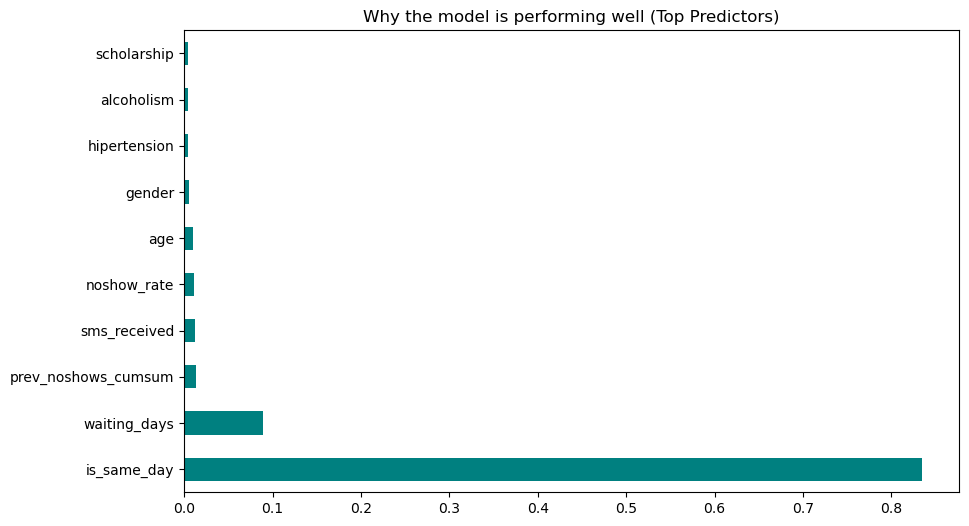

In [15]:
# 7. FEATURE IMPORTANCE VISUALIZATION
# ==========================================
plt.figure(figsize=(10, 6))
importances = pd.Series(model.feature_importances_, index=features)
importances.nlargest(10).plot(kind='barh', color='teal')
plt.title("Why the model is performing well (Top Predictors)")
plt.show()

In [17]:
# Save for future use
joblib.dump(model, "ultimate_noshow_model.pkl")

['ultimate_noshow_model.pkl']

In [18]:
import pandas as pd
import joblib
import numpy as np

# Load the perfected model
loaded_model = joblib.load("ultimate_noshow_model.pkl")

# Define three very different patient scenarios
# Features: ['age', 'gender', 'scholarship', 'hipertension', 'diabetes', 'alcoholism', 
#            'handcap', 'sms_received', 'waiting_days', 'is_same_day', 'day_of_week', 
#            'prev_noshows_cumsum', 'noshow_rate']

test_scenarios = pd.DataFrame([
    # Scenario A: The "Perfect" Patient
    # Young, booked today (same day), zero history of missing appointments.
    [25, 0, 0, 0, 0, 0, 0, 1, 0, 1, 2, 0, 0.0],
    
    # Scenario B: The "Forgetful" Patient
    # Older, booked 3 weeks ago, received an SMS, but has missed 1 out of 2 past appts.
    [55, 1, 0, 1, 1, 0, 0, 1, 21, 0, 4, 1, 0.5],
    
    # Scenario C: The "High Risk" Chronic No-Show
    # Young, booked a month ago, no SMS, has missed all 3 of their last appointments.
    [19, 0, 1, 0, 0, 0, 0, 0, 30, 0, 1, 3, 1.0]
], columns=X.columns)

# Get Probabilities
probs = loaded_model.predict_proba(test_scenarios)[:, 1]

# Display Results
results = ["Low Risk (Perfect History)", "Medium Risk (Forgetful)", "Critical Risk (Chronic No-Show)"]
for i, prob in enumerate(probs):
    print(f"Scenario: {results[i]}")
    print(f"Probability of No-Show: {prob:.2%}")
    print(f"Action: {'Call immediately!' if prob > 0.6 else 'Standard Reminder'}\n")

Scenario: Low Risk (Perfect History)
Probability of No-Show: 15.18%
Action: Standard Reminder

Scenario: Medium Risk (Forgetful)
Probability of No-Show: 61.33%
Action: Call immediately!

Scenario: Critical Risk (Chronic No-Show)
Probability of No-Show: 90.33%
Action: Call immediately!



In [19]:
# Create a "Priority Call List" from your test data
test_results = X_test.copy()
test_results['risk_score'] = loaded_model.predict_proba(X_test)[:, 1]

# Sort by highest risk
priority_list = test_results.sort_values(by='risk_score', ascending=False).head(10)

print("--- TOP 10 PATIENTS TO CALL TODAY ---")
print(priority_list[['age', 'waiting_days', 'noshow_rate', 'risk_score']])

--- TOP 10 PATIENTS TO CALL TODAY ---
        age  waiting_days  noshow_rate  risk_score
59655    43            22          1.0    0.946364
53387     9             0          1.0    0.946063
59620    42            22          1.0    0.945054
11055    32            66          1.0    0.942808
11247    32            64          1.0    0.939934
107943   37            61          1.0    0.939914
54751    14             0          1.0    0.939218
107933   32            62          1.0    0.939153
66255    50            54          1.0    0.938870
104028   32            42          1.0    0.938649
